#次元の呪い（サクサクメロンパン）の気持ち

参考文献：https://windfall.hatenablog.com/entry/2015/07/02/084623

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from ipywidgets import interact, IntSlider, FloatSlider

np.set_printoptions(precision=4, suppress=True)

In [2]:
def shell_ratio(dim, thickness_ratio):
    """
    Fraction of volume contained in the outer shell of an n-dimensional ball
    with radius 1 and shell thickness = thickness_ratio.

    shell fraction = 1 - (1 - thickness_ratio)^dim
    """
    if thickness_ratio < 0 or thickness_ratio > 1:
        raise ValueError("thickness_ratio must be in [0, 1]")
    return 1.0 - (1.0 - thickness_ratio) ** dim


def fmt_pct(x):
    return f"{100*x:.1f}%"

In [3]:
def draw_melonpan_demo(dim=3, thickness_percent=1.0, max_dim=500):
    """
    dim: dimension
    thickness_percent: shell thickness as a percentage of the radius

    Left panel:
        Visual intuition panel. The shell thickness is adjusted so that
        the 2D area fraction matches the nD shell fraction.
        (This is not a literal 2D cross-section of the nD ball.)
    """
    thickness_ratio = thickness_percent / 100.0
    ratio = shell_ratio(dim, thickness_ratio)

    dims = np.arange(1, max_dim + 1)
    ratios = shell_ratio(dims, thickness_ratio)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # Left: intuition-oriented visualization
    # -------------------------
    ax = axes[0]
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.axis("off")

    outer_r = 1.0

    # Convert shell fraction into a 2D-area-equivalent inner radius:
    # 1 - inner_r^2 = ratio  -> inner_r = sqrt(1 - ratio)
    inner_r = np.sqrt(max(0.0, 1.0 - ratio))

    outer = Circle((0, 0), outer_r, facecolor="#b97a57", edgecolor="black", lw=1.5)
    ax.add_patch(outer)

    if inner_r > 0:
        inner = Circle((0, 0), inner_r, facecolor="#f4d35e", edgecolor="none")
        ax.add_patch(inner)

    for a in np.linspace(-0.8, 0.8, 5):
        ax.plot([-0.9, 0.9], [a, a], color="white", alpha=0.35, lw=1)
        ax.plot([a, a], [-0.9, 0.9], color="white", alpha=0.35, lw=1)

    ax.set_title(
        f"{dim}D Melon Pan\n"
        f"Shell thickness: {thickness_percent:.2f}% of radius\n"
        f"Shell fraction: {100*ratio:.1f}%"
    )

    # -------------------------
    # Right: shell fraction vs dimension
    # -------------------------
    ax = axes[1]
    ax.plot(dims, ratios, lw=2)
    ax.scatter([dim], [ratio], s=80, zorder=3)
    ax.set_xlabel("Dimension n")
    ax.set_ylabel("Fraction in shell")
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title("As dimension grows, almost everything moves into the shell")

    for ref in [3, 30, 100, 500]:
        if ref <= max_dim:
            ax.axvline(ref, color="gray", alpha=0.15, lw=1)

    plt.tight_layout()
    plt.show()

    print(f"n = {dim}")
    print(f"Shell thickness = {thickness_percent:.2f}% of radius")
    print(f"Shell fraction = {ratio:.6f} ({100*ratio:.1f}%)")
    print(f"Displayed inner radius (for intuition only) = {inner_r:.6f}")

###インタラクティブデモ

左図は、メロンパンの「サクサク部分」の体積比を、円の面積に変換して可視化したものです。`dim`を変えて遊んでください。

In [4]:
interact(
    draw_melonpan_demo,
    dim=IntSlider(value=3, min=1, max=500, step=1, description="dim"),
    thickness_percent=FloatSlider(value=1.0, min=0.1, max=20.0, step=0.1, description="shell %"),
    max_dim=IntSlider(value=500, min=50, max=2000, step=50, description="max dim")
)

interactive(children=(IntSlider(value=3, description='dim', max=500, min=1), FloatSlider(value=1.0, descriptio…

<function __main__.draw_melonpan_demo(dim=3, thickness_percent=1.0, max_dim=500)>

#高次元特徴空間での「距離」を考える



In [5]:
def l2_normalize(X, axis=1, eps=1e-12):
    norm = np.linalg.norm(X, axis=axis, keepdims=True)
    return X / np.clip(norm, eps, None)

def pairwise_distances_to_query(X, q):
    return np.linalg.norm(X - q[None, :], axis=1)


###ユークリッド距離の挙動
ランダムにサンプルした$dim$次元ベクトルたち``X``について、ランダム基準点``q``からの距離を比較します。

高次元空間にランダムベクトルをばらまくと、ノルムもユークリッド距離もそれぞれ同じ値に近づきます。（ちなみに、ランダムベクトルであれば、コサイン類似度も、ほとんどのベクトルが互いにほぼ直交するので、0に近づきます。）

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def demo_distance_concentration(dim=100, n_samples=2000):
    rng = np.random.default_rng(0)

    q = rng.normal(size=dim)
    X = rng.normal(size=(n_samples, dim))

    norms = np.linalg.norm(X, axis=1)
    dists = pairwise_distances_to_query(X, q)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(norms, bins=40, alpha=0.8)
    axes[0].set_title(f"Norms in {dim}D")
    axes[0].set_xlabel("||x||")
    axes[0].set_ylabel("count")
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(dists, bins=40, alpha=0.8)
    axes[1].set_title(f"Euclidean distances to query in {dim}D")
    axes[1].set_xlabel("||x - q||")
    axes[1].set_ylabel("count")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"dimension = {dim}")

    print("\n[Norm concentration]")
    print(f"mean norm = {norms.mean():.4f}")
    print(f"std norm  = {norms.std():.4f}")
    print(f"min norm  = {norms.min():.4f}")
    print(f"max norm  = {norms.max():.4f}")
    print(f"relative spread (std/mean) = {norms.std()/norms.mean():.4f}")

    print("\n[Distance concentration]")
    print(f"mean distance = {dists.mean():.4f}")
    print(f"std distance  = {dists.std():.4f}")
    print(f"min distance  = {dists.min():.4f}")
    print(f"max distance  = {dists.max():.4f}")
    print(f"relative spread (std/mean) = {dists.std()/dists.mean():.4f}")
    print(f"contrast ((max-min)/min)   = {(dists.max()-dists.min())/dists.min():.4f}")

In [7]:
interact(demo_distance_concentration, dim=IntSlider(value=2, min=2, max=2000, step=10));

interactive(children=(IntSlider(value=2, description='dim', max=2000, min=2, step=10), IntSlider(value=2000, d…

###演習：高次元特徴量空間での分類
高次元空間にランダムベクトルをばらまき、超平面で分割することで、擬似的に2クラスのデータを作っています。見やすいように、境界付近に適当なマージンを設けています。

- ``n_per_class``: 各クラスのデータ数：
- ``X``: dim次元特徴ベクトル, shape:(2*n_per_class, dim)
- ``y``: クラスラベル (0か1), shape:(2*n_per_class)

In [8]:
def make_hyperplane_data(
    dim=128,
    n_per_class=300,
    margin=0.5,
    seed=0,
):
    """
    Generate random high-dimensional vectors, then assign class labels
    according to which side of a random separating hyperplane they lie on.

    Parameters
    ----------
    dim : int
        Feature dimension.
    n_per_class : int
        Number of samples per class to keep.
    margin : float
        Keep only samples with |w^T x| >= margin so that the two classes
        are more clearly separated.
    scale_jitter : float
        Amount of multiplicative norm variation.
    seed : int
        Random seed.

    Returns
    -------
    X : ndarray, shape (2*n_per_class, dim)
        Feature matrix.
    y : ndarray, shape (2*n_per_class,)
        Labels (0 or 1).
    w : ndarray, shape (dim,)
        Unit normal vector of the separating hyperplane.
    q : ndarray, shape (dim,)
        Query direction, chosen along the class-0 side of the hyperplane.
    """
    rng = np.random.default_rng(seed)

    # random hyperplane normal
    w = rng.normal(size=dim)
    w = w / np.linalg.norm(w)

    # oversample, because after margin filtering we throw many away
    n_try = max(10 * n_per_class, 2000)

    while True:
        X0 = rng.normal(size=(n_try, dim))
        score = X0 @ w

        # class 0: one side of the hyperplane
        # class 1: the other side
        mask0 = score >= margin
        mask1 = score <= -margin

        if np.sum(mask0) >= n_per_class and np.sum(mask1) >= n_per_class:
            X_class0 = X0[mask0][:n_per_class]
            X_class1 = X0[mask1][:n_per_class]
            break

        # if not enough points, try again with more samples
        n_try *= 2

    X = np.vstack([X_class0, X_class1])
    y = np.array([0] * n_per_class + [1] * n_per_class)

    # query points toward class 0 side
    q = w * 3.0

    return X, y, w, q

## 課題：

クエリベクトルとXの内積を計算する関数``inner_products_to_query``、コサイン類似度を計算する関数``cosine_similarities_to_query``を完成させて、デモを動かしましょう。

In [9]:

def inner_products_to_query(X, q):
    """
    TODO:
    Compute the inner product between each row of X and q.

    Parameters
    ----------
    X : ndarray of shape (N, D)
        Feature matrix.
    q : ndarray of shape (D,)
        Query vector.

    Returns
    -------
    ips : ndarray of shape (N,)
        Inner products between each row of X and q.
    """
    # Placeholder output for exercise
    return X @ q

def cosine_similarities_to_query(X, q, eps=1e-12):
    """
    TODO:
    Compute cosine similarity between each row of X and q.

    Parameters
    ----------
    X : ndarray of shape (N, D)
        Feature matrix.
    q : ndarray of shape (D,)
        Query vector.
    eps : float
        Small value to avoid division by zero.

    Returns
    -------
    coss : ndarray of shape (N,)
        Cosine similarities between each row of X and q.
    """

    Xn = X / np.clip(np.linalg.norm(X, axis=1, keepdims=True), eps, None)
    qn = q / max(np.linalg.norm(q), eps)

    # Placeholder output for exercise
    return Xn @ qn

def compare_three_metrics_hyperplane(
    dim=128,
    n_per_class=300,
    bins=30,
    seed=0,
    ):

    X, y, w, q = make_hyperplane_data(
        dim=dim,
        n_per_class=n_per_class,
        seed=seed,
    )

    dists = pairwise_distances_to_query(X, q)
    ips = inner_products_to_query(X, q)
    coss = cosine_similarities_to_query(X, q)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    dist_range = (dists.min(), dists.max())
    ip_range   = (ips.min(), ips.max())
    cos_range  = (coss.min(), coss.max())

    axes[0].hist(dists[y == 0], bins=bins, range=dist_range, alpha=0.7, label="class 0")
    axes[0].hist(dists[y == 1], bins=bins, range=dist_range, alpha=0.7, label="class 1")
    axes[0].set_title("Euclidean distance")
    axes[0].set_xlabel("distance")
    axes[0].legend()

    axes[1].hist(ips[y == 0], bins=bins, range=ip_range, alpha=0.7, label="class 0")
    axes[1].hist(ips[y == 1], bins=bins, range=ip_range, alpha=0.7, label="class 1")
    axes[1].set_title("Raw inner product")
    axes[1].set_xlabel("x^T q")
    axes[1].legend()

    axes[2].hist(coss[y == 0], bins=bins, range=cos_range, alpha=0.7, label="class 0")
    axes[2].hist(coss[y == 1], bins=bins, range=cos_range, alpha=0.7, label="class 1")
    axes[2].set_title("Cosine similarity")
    axes[2].set_xlabel("cosine")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("Top-1 class by each metric:")
    print("Euclidean distance:", y[np.argmin(dists)])
    print("Inner product     :", y[np.argmax(ips)])
    print("Cosine similarity :", y[np.argmax(coss)])

    print("\nMean values by class:")
    print(f"Euclidean: class0={dists[y==0].mean():.4f}, class1={dists[y==1].mean():.4f}")
    print(f"InnerProd: class0={ips[y==0].mean():.4f}, class1={ips[y==1].mean():.4f}")
    print(f"Cosine   : class0={coss[y==0].mean():.4f}, class1={coss[y==1].mean():.4f}")

可視化（``dim``を変えて試してください）

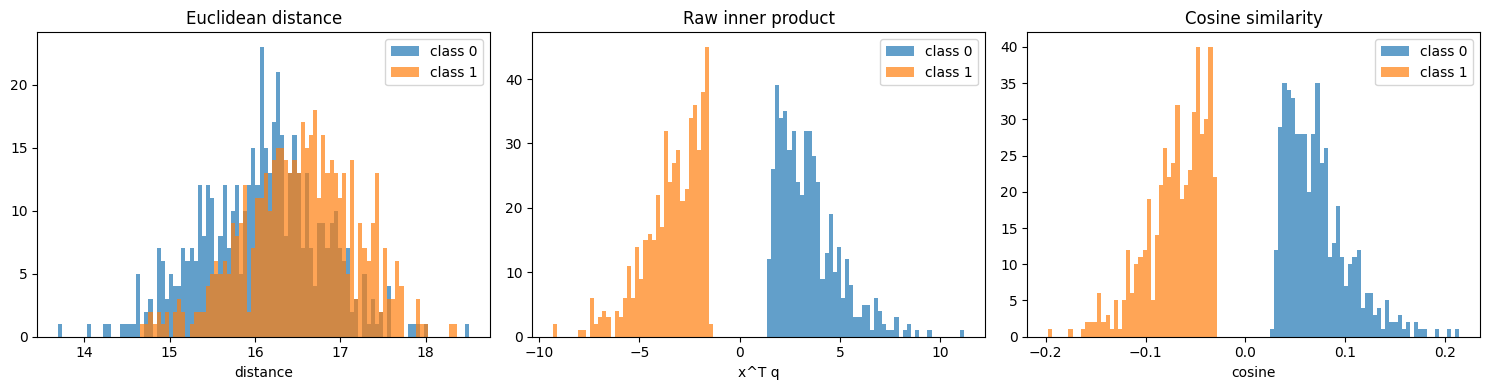

Top-1 class by each metric:
Euclidean distance: 0
Inner product     : 0
Cosine similarity : 0

Mean values by class:
Euclidean: class0=16.0756, class1=16.5178
InnerProd: class0=3.4294, class1=-3.3427
Cosine   : class0=0.0715, class1=-0.0696


In [10]:
compare_three_metrics_hyperplane(
    dim=256,
    n_per_class=500,
    bins=100,
    seed=0,
)